# 01 — API Exploration

Goal: understand the raw shape of the Blizzard AH data before we build the processing pipeline.

Questions we want to answer:
1. What does the raw auction object look like?
2. What's the price distribution (after converting copper → gold)?
3. What items show up most often?
4. What does the Item API return for a given item_id?
5. What data quality issues exist (missing buyout, duplicates, etc.)?

In [1]:
import sys
sys.path.insert(0, '..')  # so we can import from src/

import pandas as pd
import matplotlib.pyplot as plt

from src.ingestion.snapshot_store import SnapshotStore
from src.ingestion.blizzard_client import BlizzardClient
from src.utils.config import get_settings

settings = get_settings()
REALM_ID = settings.blizzard_realm_id
print(f'Realm ID: {REALM_ID}')

Realm ID: 3676


## 1. Load the snapshot

In [2]:
store = SnapshotStore()
snapshots = store.list_snapshots(REALM_ID)
print(f'Snapshots on disk: {len(snapshots)}')

# Load the most recent one
data = store.load(snapshots[-1])
print(f'Snapshot time: {data["snapshot_time"]}')
print(f'Auction count: {data["auction_count"]}')

Snapshots on disk: 1
Snapshot time: 20260416T205022Z
Auction count: 100253


## 2. Load into a DataFrame

We flatten the nested `item` dict and convert copper → gold.

In [3]:
auctions = data['auctions']

rows = []
for a in auctions:
    rows.append({
        'auction_id':  a['id'],
        'item_id':     a['item']['id'],
        'buyout_copper': a.get('buyout', None),   # some auctions are bid-only
        'bid_copper':    a.get('bid', None),
        'quantity':    a['quantity'],
        'time_left':   a['time_left'],
    })

df = pd.DataFrame(rows)

# Convert to gold (1 gold = 10,000 copper)
df['buyout_gold'] = df['buyout_copper'] / 10_000
df['unit_price_gold'] = df['buyout_gold'] / df['quantity']

print(df.shape)
df.head()

(100253, 8)


,auction_id,item_id,buyout_copper,bid_copper,quantity,time_left,buyout_gold,unit_price_gold
0,973974136,178927,175282200,NaN,1,SHORT,17528.22,17528.22
1,973974958,245341,489500,369500.0,1,SHORT,48.95,48.95
2,973974999,245341,489500,369500.0,1,SHORT,48.95,48.95
3,973975049,245341,489500,369500.0,1,SHORT,48.95,48.95
4,973975088,245341,489500,369500.0,1,SHORT,48.95,48.95


## 3. Basic stats

In [4]:
print('=== Missing buyout (bid-only auctions) ===')
print(df['buyout_copper'].isna().sum(), 'auctions have no buyout')
print()

print('=== time_left distribution ===')
print(df['time_left'].value_counts())
print()

print('=== Price distribution (gold, buyout-only auctions) ===')
df_buyout = df[df['buyout_gold'].notna()]
print(df_buyout['unit_price_gold'].describe())

=== Missing buyout (bid-only auctions) ===
0 auctions have no buyout

=== time_left distribution ===
time_left
VERY_LONG    55303
LONG         37633
MEDIUM        5083
SHORT         2234
Name: count, dtype: int64

=== Price distribution (gold, buyout-only auctions) ===
count    1.002530e+05
mean     2.620426e+04
std      2.646528e+05
min      1.000000e-02
25%      3.499900e+02
50%      2.109960e+03
75%      9.899970e+03
max      1.000000e+07
Name: unit_price_gold, dtype: float64


## 4. Most listed items

In [5]:
top_items = df['item_id'].value_counts().head(20)
print('Top 20 most-listed item IDs:')
print(top_items)

Top 20 most-listed item IDs:
item_id
82800     6056
194017     766
239674     314
239675     295
244752     264
240161     211
222853     197
268475     195
244708     194
244712     189
244178     161
258915     157
239676     150
258919     149
258934     141
258931     140
238017     140
238015     139
240959     136
258932     132
Name: count, dtype: int64


## 5. Fetch item names from the API

Right now we only have item IDs — we need to call the Item API to get names.
Let's look up the top 5 to understand what's being sold.

In [6]:
client = BlizzardClient(settings.blizzard_client_id, settings.blizzard_client_secret)

top_item_ids = top_items.index[:5].tolist()

for item_id in top_item_ids:
    item = client.get_item(item_id)
    name = item.get('name', 'Unknown')
    quality = item.get('quality', {}).get('name', '?')
    item_class = item.get('item_class', {}).get('name', '?')
    count = top_items[item_id]
    print(f'{item_id:>8} | {count:>5} listings | [{quality}] {name} ({item_class})')

   82800 |  6056 listings | [Rare] Pet Cage (Battle Pets)
  194017 |   766 listings | [Uncommon] Wildercloth Bag (Container)
  239674 |   314 listings | [Rare] Courtly Cloak (Armor)
  239675 |   295 listings | [Rare] Courtly Shoulders (Armor)
  244752 |   264 listings | [Rare] Evercore Shade (Armor)


## 6. Price distribution plot

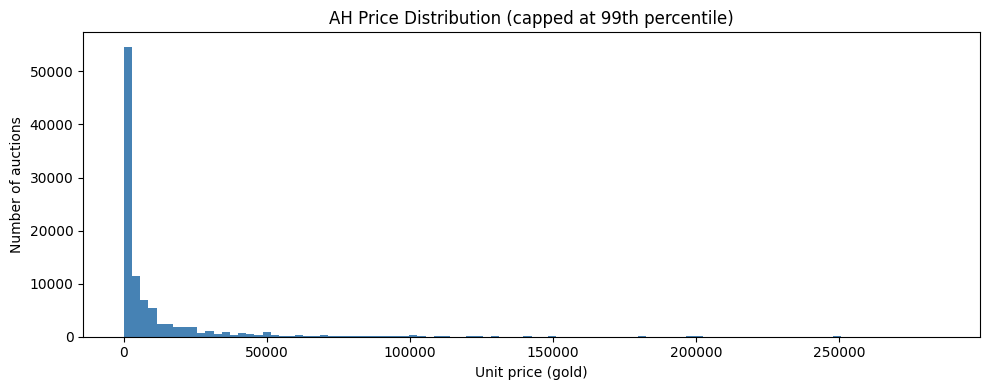

Showing prices up to 285000g (99250 auctions)


In [7]:
# Cap at 99th percentile so outliers don't squish the chart
cap = df_buyout['unit_price_gold'].quantile(0.99)
plot_data = df_buyout[df_buyout['unit_price_gold'] <= cap]['unit_price_gold']

plt.figure(figsize=(10, 4))
plt.hist(plot_data, bins=100, color='steelblue', edgecolor='none')
plt.xlabel('Unit price (gold)')
plt.ylabel('Number of auctions')
plt.title('AH Price Distribution (capped at 99th percentile)')
plt.tight_layout()
plt.show()

print(f'Showing prices up to {cap:.0f}g ({plot_data.shape[0]} auctions)')